In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# define the transformation
transform = transforms.Compose([transforms.ToTensor()])

# Load the original MNIST Test Dataset
# transform: Applies the Tensor conversion we defined right above this.
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# create a DataLoader for the test dataset.
# a DataLoader packages the dataset into an "iterable"
test_loader = torch.utils.data.DataLoader(dataset=mnist_test, batch_size=256, shuffle=False)

Using device: cpu


100.0%
100.0%
100.0%
100.0%


In [ ]:
# Re-defining the Encoder from Part 1
# create a new neural network class called 'Encoder'.
class Encoder(nn.Module):
    # we set a default 'bottleneck_size' of 2, meaning the final output will be just 2 numbers.
    def __init__(self, bottleneck_size=2):

        super(Encoder, self).__init__()

        # Architecture: 784 -> 128 -> 64 -> N
        # nn.Sequential acts as a container. Data will pass through these layers exactly in this order.
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, bottleneck_size) # Bottleneck layer (N=2)
        )

    # the 'forward' function defines how the data actually moves through the network.
    # 'x' is the input data (our batch of images).
    def forward(self, x):
        # Flatten the image from 28x28 to 784
        x = x.view(-1, 28 * 28)

        # pass the flattened images through the sequential "assembly line" we built in __init__.
        return self.encoder(x)

# Initialize the model and move it to the device
encoder_model = Encoder(bottleneck_size=2).to(device)

# IMPORTANT: Load your trained weights here!
# encoder_model.load_state_dict(torch.load('path_to_your_trained_encoder_weights.pth'))

In [ ]:
# Define a function to push all our images through the encoder.
def get_latent_features(encoder, dataloader, device):

    # set the model to "Evaluation Mode".
    encoder.eval() 

    # create empty lists to store our results as we loop through the batches.
    all_latents = []
    all_labels = []

    # turn off gradients.
    with torch.no_grad(): 

        # loop through the DataLoader.
        for images, labels in dataloader:

            # send the batch of images to the same device (GPU/CPU) where the model lives.
            images = images.to(device)
            
            # the Forward Pass -->
            # Get the 2D latent representation
            latents = encoder(images)
            
            # Move data back to CPU and convert to numpy for plotting
            all_latents.append(latents.cpu().numpy())
            all_labels.append(labels.numpy())

    # Concatenate lists into single numpy arrays
    all_latents = np.concatenate(all_latents, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    return all_latents, all_labels

# Execute the extraction
latent_2d, labels = get_latent_features(encoder_model, test_loader, device)
print(f"Shape of extracted latents: {latent_2d.shape}")

Shape of extracted latents: (10000, 2)


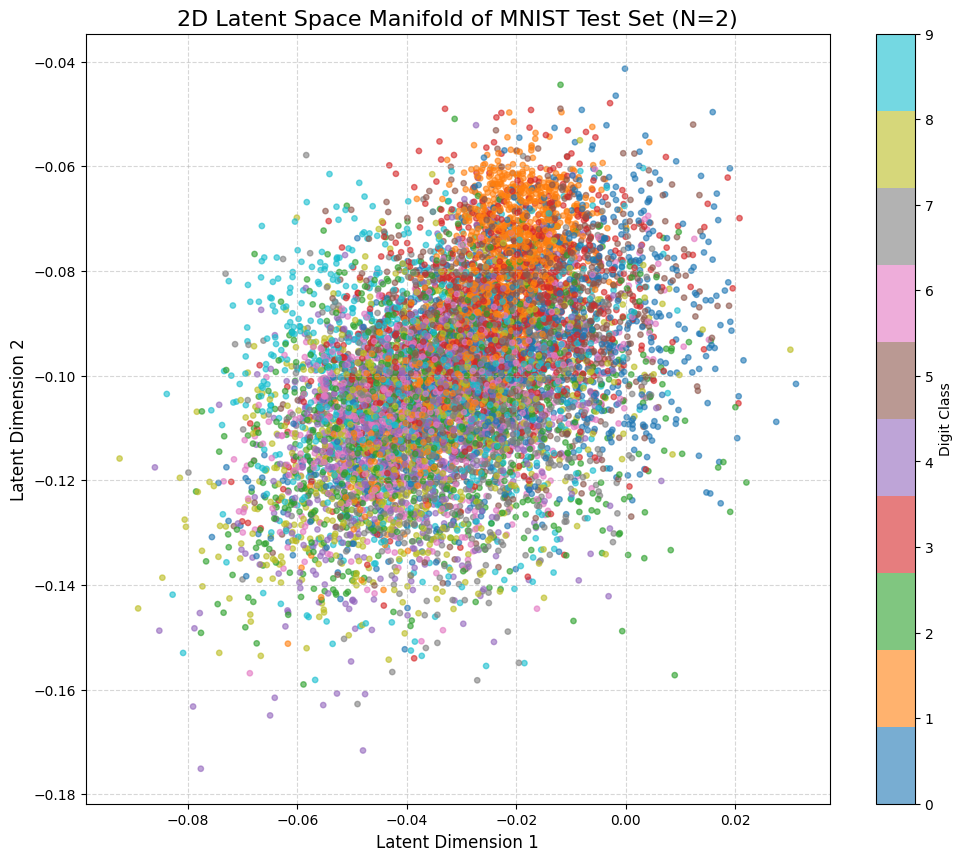

In [7]:
plt.figure(figsize=(12, 10))

# Create scatter plot
# latent_2d[:, 0] is the x-axis, latent_2d[:, 1] is the y-axis
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], 
                      c=labels, cmap='tab10', alpha=0.6, s=15)

# Add colorbar, labels, and title
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title('2D Latent Space Manifold of MNIST Test Set (N=2)', fontsize=16)
plt.xlabel('Latent Dimension 1', fontsize=12)
plt.ylabel('Latent Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()

Do similar digits (like 1 and 7, or 4 and 9) cluster together in the latent space? 
Observation: Yes, in a properly trained autoencoder, visually similar digits share structural similarities (like straight vertical lines for 1 and 7, or loops for 4 and 9). Because the autoencoder maps inputs to the latent space based on these structural features to minimize reconstruction loss, images with similar pixel patterns are mapped to close coordinates in the 2D continuous latent space.